# Bounding box detection - Racoon data


## Data files
- images_racoon.rar: contain images of racoons
- train_labels.cv: contains coordinates for bounding box for every image

###Install TensorFlow Object Detection API
-Please make sure you have installed tensorflow or tensorflow-gpu already.

-For latest install instructions, check the github page or readthedocs site for this API.

In [0]:
!git clone https://github.com/tensorflow/models

In [4]:
#Verify that models folder exist
!ls -l

total 8
drwxr-xr-x 7 root root 4096 Nov  3 07:13 models
drwxr-xr-x 1 root root 4096 Oct 25 16:58 sample_data


In [5]:
#Multiple folders including object_detection should exist in models/research folder
!ls -l models/research/

total 280
drwxr-xr-x  2 root root 4096 Nov  3 07:13 a3c_blogpost
drwxr-xr-x  2 root root 4096 Nov  3 07:13 adversarial_crypto
drwxr-xr-x  4 root root 4096 Nov  3 07:13 adversarial_logit_pairing
drwxr-xr-x  3 root root 4096 Nov  3 07:13 adversarial_text
drwxr-xr-x  2 root root 4096 Nov  3 07:13 adv_imagenet_models
drwxr-xr-x  2 root root 4096 Nov  3 07:13 astronet
drwxr-xr-x  3 root root 4096 Nov  3 07:13 attention_ocr
drwxr-xr-x  3 root root 4096 Nov  3 07:13 audioset
drwxr-xr-x  2 root root 4096 Nov  3 07:13 autoaugment
drwxr-xr-x  3 root root 4096 Nov  3 07:13 autoencoder
drwxr-xr-x  4 root root 4096 Nov  3 07:13 brain_coder
drwxr-xr-x 11 root root 4096 Nov  3 07:13 cognitive_mapping_and_planning
drwxr-xr-x  4 root root 4096 Nov  3 07:13 cognitive_planning
drwxr-xr-x  4 root root 4096 Nov  3 07:13 compression
drwxr-xr-x  7 root root 4096 Nov  3 07:13 cvt_text
drwxr-xr-x  3 root root 4096 Nov  3 07:13 deep_contextual_bandits
drwxr-xr-x  9 root root 4096 Nov  3 07:13 deeplab
drwxr-xr-x

Install other dependencies including protobuf compiler

### Import the necessary libraries including protobuf compiler

In [6]:
!apt-get -qq install protobuf-compiler python-pil python-lxml python-tk
!pip install --user Cython  --quiet
!pip install --user contextlib2 --quiet
!pip install --user jupyter --quiet
!pip install --user matplotlib --quiet

Selecting previously unselected package python-bs4.
(Reading database ... 132681 files and directories currently installed.)
Preparing to unpack .../0-python-bs4_4.6.0-1_all.deb ...
Unpacking python-bs4 (4.6.0-1) ...
Selecting previously unselected package python-pkg-resources.
Preparing to unpack .../1-python-pkg-resources_39.0.1-2_all.deb ...
Unpacking python-pkg-resources (39.0.1-2) ...
Selecting previously unselected package python-chardet.
Preparing to unpack .../2-python-chardet_3.0.4-1_all.deb ...
Unpacking python-chardet (3.0.4-1) ...
Selecting previously unselected package python-six.
Preparing to unpack .../3-python-six_1.11.0-2_all.deb ...
Unpacking python-six (1.11.0-2) ...
Selecting previously unselected package python-webencodings.
Preparing to unpack .../4-python-webencodings_0.5-2_all.deb ...
Unpacking python-webencodings (0.5-2) ...
Selecting previously unselected package python-html5lib.
Preparing to unpack .../5-python-html5lib_0.999999999-1_all.deb ...
Unpacking pyt

###Protobuf compilation

- Convert .pb files to python code in object detection folder

In [7]:
%cd models/research
!protoc object_detection/protos/*.proto --python_out=.

/content/models/research


In [8]:
!ls -l object_detection/protos

total 724
-rw-r--r-- 1 root root   6848 Nov  3 07:21 anchor_generator_pb2.py
-rw-r--r-- 1 root root    747 Nov  3 07:13 anchor_generator.proto
-rw-r--r-- 1 root root   4359 Nov  3 07:21 argmax_matcher_pb2.py
-rw-r--r-- 1 root root   1151 Nov  3 07:13 argmax_matcher.proto
-rw-r--r-- 1 root root   2175 Nov  3 07:21 bipartite_matcher_pb2.py
-rw-r--r-- 1 root root    350 Nov  3 07:13 bipartite_matcher.proto
-rw-r--r-- 1 root root   6208 Nov  3 07:21 box_coder_pb2.py
-rw-r--r-- 1 root root    656 Nov  3 07:13 box_coder.proto
-rw-r--r-- 1 root root  35788 Nov  3 07:21 box_predictor_pb2.py
-rw-r--r-- 1 root root   7366 Nov  3 07:13 box_predictor.proto
-rw-r--r-- 1 root root  24908 Nov  3 07:21 calibration_pb2.py
-rw-r--r-- 1 root root   2876 Nov  3 07:13 calibration.proto
-rw-r--r-- 1 root root  13121 Nov  3 07:21 eval_pb2.py
-rw-r--r-- 1 root root   3642 Nov  3 07:13 eval.proto
-rw-r--r-- 1 root root   3445 Nov  3 07:21 faster_rcnn_box_coder_pb2.py
-rw-r--r-- 1 root root    531 Nov  3 07:13 

Setup environment variable

In [9]:
%set_env PYTHONPATH=$PYTHONPATH:/content/models/research:/content/models/research/slim

env: PYTHONPATH=$PYTHONPATH:/content/models/research:/content/models/research/slim


Test Installation

In [10]:
#To be run from models/research folder
!python object_detection/builders/model_builder_test.py

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.



Running tests under Python 3.6.8: /usr/bin/python3
[ RUN      ] ModelBuilderTest.test_create_experimental_model
[       OK ] ModelBuilderTest.test_create_experimental_model
[ RUN      ] ModelBuilderTest.test_create_faster_rcnn_model_from_config_with_example_miner
[       OK ] ModelBuilderTest.test_create_faster_rcnn_model_from_config_with_example_miner
[ RUN      ] ModelBuilderTest.test_create_faster_rcnn_models_from_config_faster_rcnn_with_matmul
[       OK ] ModelBuilderTest.test_create_faster_rcnn_models_from_config_faster_rcnn_with_matmul
[ RUN      ] ModelBuilderTest.test_create_faster_rcnn_models_from_config_faster_rcnn_

In [16]:
#Come to the home directory
%cd /content


/content


In [17]:
!ls -l

total 12
drwx------ 3 root root 4096 Nov  3 07:35 drive
drwxr-xr-x 7 root root 4096 Nov  3 07:13 models
drwxr-xr-x 1 root root 4096 Oct 25 16:58 sample_data


In [0]:
from google.colab import drive

In [15]:
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


### Change directory


### Load the training data from train.csv file

Load csv file as dataframe

In [22]:
import pandas as pd
df = pd.read_csv('drive/My Drive/lab_residency9/lab_ext/train_labels.csv')
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127


In [23]:
#How many object across all images
df.shape

(173, 8)

In [24]:
#List of labels
df['class'].unique()

array(['raccoon'], dtype=object)

In [25]:
#Number of labels
len(df['class'].unique())

1

Label encode Class 

In [0]:
from sklearn import preprocessing

In [27]:
le = preprocessing.LabelEncoder()
df['label'] = le.fit_transform(df['class'])
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax,label
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118,0
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431,0
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290,0
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298,0
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127,0


In [28]:
#unique values in the label
df.label.unique()

array([0])

In [29]:
#Object detection API expects index to start from 1 (and not 0)
df['label'] = df['label'] + 1
df.label.unique()

array([1])

In [30]:
#Create a dictionary of Label and Clas
label_class_dict = dict(zip(df['label'], df['class']))
label_class_dict

{1: 'raccoon'}

Split data between training and test

In [0]:
import numpy as np

#80% of the data will be used for training
mask = np.random.rand(len(df)) < 0.8
train_df = df[mask]
test_df = df[~mask]

### Print the shape of the train dataset

In [32]:
train_df.shape, test_df.shape

((144, 9), (29, 9))

Visualizing the data

In [0]:
from matplotlib import pyplot as plt
import cv2

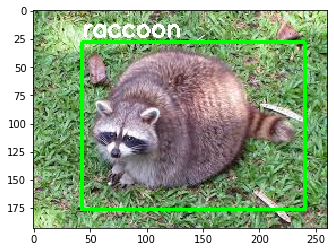

In [44]:
#Pickup a random image number
img_num = np.random.randint(0, df.shape[0])

#Read the image
img_file = df.loc[img_num,'filename']
img = cv2.imread('drive/My Drive/lab_residency9/lab_ext/images/' + img_file)

#Find all rows which have same file name
rows_with_file = df[df['filename'] == img_file].index.tolist()

#Draw rectangle(s) as per bounding box information
for i in rows_with_file:

    #Get bounding box
    xmin, ymin, xmax, ymax = df.loc[i, ['xmin', 'ymin', 'xmax', 'ymax']]
    #Get Label
    label = df.loc[i, 'class']
    #Add bounding box
    cv2.rectangle(img, (xmin,ymin), (xmax, ymax), (0,255,0), 2)
    #Add text
    cv2.putText(img,label,(xmin, ymin-5),cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

#Convert BGR format (used by opencv to RGB format used by matplotlib)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Draw image using matplotlib
plt.imshow(img)
plt.show()

Save training and test data as csv

In [0]:
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)


###Generate tfrecord from CSV
Tensorflow object detection API requires data in tfrecord format. This can be done using generate_tfrecord.py file.

In [47]:
!ls -l

total 24
drwx------ 3 root root 4096 Nov  3 07:35 drive
drwxr-xr-x 7 root root 4096 Nov  3 07:13 models
drwxr-xr-x 1 root root 4096 Oct 25 16:58 sample_data
-rw-r--r-- 1 root root 1425 Nov  3 08:08 test.csv
-rw-r--r-- 1 root root 6894 Nov  3 08:08 train.csv


In [49]:
#To be done for colab only - copy generate_tfrecord.py file in current directory
from google.colab import files
files.upload()

Saving generate_tfrecord.py to generate_tfrecord.py


{'generate_tfrecord.py': b'"""\r\nUsage:\r\n\r\n# Create train data:\r\npython generate_tfrecord.py --label=<LABEL> --csv_input=<PATH_TO_ANNOTATIONS_FOLDER>/train_labels.csv  --output_path=<PATH_TO_ANNOTATIONS_FOLDER>/train.record\r\n\r\n# Create test data:\r\npython generate_tfrecord.py --label=<LABEL> --csv_input=<PATH_TO_ANNOTATIONS_FOLDER>/test_labels.csv  --output_path=<PATH_TO_ANNOTATIONS_FOLDER>/test.record\r\n"""\r\n\r\nfrom __future__ import division\r\nfrom __future__ import print_function\r\nfrom __future__ import absolute_import\r\n\r\nimport os\r\nimport io\r\nimport pandas as pd\r\nimport tensorflow as tf\r\n#import sys\r\n#sys.path.append("../../models/research")\r\n\r\nfrom PIL import Image\r\nfrom object_detection.utils import dataset_util\r\nfrom collections import namedtuple, OrderedDict\r\n\r\nflags = tf.app.flags\r\nflags.DEFINE_string(\'csv_input\', \'\', \'Path to the CSV input\')\r\nflags.DEFINE_string(\'output_path\', \'\', \'Path to output TFRecord\')\r\nflags

In [0]:
#Make sure models/research folder is on system path
#Please change folder name is you are using a diffrent folder structure
import sys
sys.path.append('/content/models/research')

In [52]:
#generate tfrecord for training data
!python generate_tfrecord.py --csv_input=train.csv  --output_path=train.record --img_path=drive/My\ Drive/lab_residency9/lab_ext/images

Successfully created the TFRecords: /content/train.record


In [53]:
#generate tfrecord for test data
!python generate_tfrecord.py --csv_input=test.csv  --output_path=test.record --img_path=drive/My\ Drive/lab_residency9/lab_ext/images

Successfully created the TFRecords: /content/test.record


In [54]:
#train.record and test.record files should be available now
!ls -l

total 10844
drwx------ 3 root root    4096 Nov  3 07:35 drive
-rw-r--r-- 1 root root    4440 Nov  3 08:15 generate_tfrecord.py
drwxr-xr-x 7 root root    4096 Nov  3 07:13 models
drwxr-xr-x 1 root root    4096 Oct 25 16:58 sample_data
-rw-r--r-- 1 root root    1425 Nov  3 08:08 test.csv
-rw-r--r-- 1 root root 1873419 Nov  3 08:19 test.record
-rw-r--r-- 1 root root    6894 Nov  3 08:08 train.csv
-rw-r--r-- 1 root root 9192342 Nov  3 08:18 train.record


###Create Label File

In [0]:
#Build a pbtxt label file using label and class name
#This is required by Object detection API
#You can prepare it manually as well. 
#A sample pbtxt file can be found at object_detection/data/pascal_label_map.pbtxt
pbtxt_file_txt = ''
for label in sorted(label_class_dict.keys()):
    
    pbtxt_file_txt += "item {\n  id: " + str(label) + "\n  name: '" +  label_class_dict[label] + "'\n}\n\n"

with open('racoon_voc.pbtxt','w') as pbfile:
    pbfile.write(pbtxt_file_txt)

In [63]:
!ls -l

total 85604
drwx------ 3 root   root     4096 Nov  3 07:35 drive
-rw-r--r-- 1 root   root     4440 Nov  3 08:15 generate_tfrecord.py
drwxr-xr-x 7 root   root     4096 Nov  3 07:13 models
-rw-r--r-- 1 root   root       36 Nov  3 08:28 pascal_voc.pbtxt
-rw-r--r-- 1 root   root       36 Nov  3 08:33 racoon_voc.pbtxt
drwxr-xr-x 1 root   root     4096 Oct 25 16:58 sample_data
drwxr-xr-x 3 345018 5000     4096 Feb  1  2018 ssd_mobilenet_v1_coco_2018_01_28
-rw-r--r-- 1 root   root 76541073 Feb 10  2018 ssd_mobilenet_v1_coco_2018_01_28.tar.gz
-rw-r--r-- 1 root   root     1425 Nov  3 08:08 test.csv
-rw-r--r-- 1 root   root  1873419 Nov  3 08:19 test.record
-rw-r--r-- 1 root   root     6894 Nov  3 08:08 train.csv
-rw-r--r-- 1 root   root  9192342 Nov  3 08:18 train.record


In [64]:
#Review the file content
!cat racoon_voc.pbtxt

item {
  id: 1
  name: 'raccoon'
}



###Download a pre-trained model
A list of pre-trained models is available at TensorFlow model zoo. We will use 'ssd_mobilenet_v1_coco' model for transfer learning.


In [0]:
#Download the model from zoo
!wget -q http://download.tensorflow.org/models/object_detection/ssd_mobilenet_v1_coco_2018_01_28.tar.gz

In [65]:
!ls -l

total 85604
drwx------ 3 root   root     4096 Nov  3 07:35 drive
-rw-r--r-- 1 root   root     4440 Nov  3 08:15 generate_tfrecord.py
drwxr-xr-x 7 root   root     4096 Nov  3 07:13 models
-rw-r--r-- 1 root   root       36 Nov  3 08:28 pascal_voc.pbtxt
-rw-r--r-- 1 root   root       36 Nov  3 08:33 racoon_voc.pbtxt
drwxr-xr-x 1 root   root     4096 Oct 25 16:58 sample_data
drwxr-xr-x 3 345018 5000     4096 Feb  1  2018 ssd_mobilenet_v1_coco_2018_01_28
-rw-r--r-- 1 root   root 76541073 Feb 10  2018 ssd_mobilenet_v1_coco_2018_01_28.tar.gz
-rw-r--r-- 1 root   root     1425 Nov  3 08:08 test.csv
-rw-r--r-- 1 root   root  1873419 Nov  3 08:19 test.record
-rw-r--r-- 1 root   root     6894 Nov  3 08:08 train.csv
-rw-r--r-- 1 root   root  9192342 Nov  3 08:18 train.record


In [66]:
#Extract tar file content
!tar -xvf ssd_mobilenet_v1_coco_2018_01_28.tar.gz

ssd_mobilenet_v1_coco_2018_01_28/
ssd_mobilenet_v1_coco_2018_01_28/model.ckpt.index
ssd_mobilenet_v1_coco_2018_01_28/checkpoint
ssd_mobilenet_v1_coco_2018_01_28/pipeline.config
ssd_mobilenet_v1_coco_2018_01_28/model.ckpt.data-00000-of-00001
ssd_mobilenet_v1_coco_2018_01_28/model.ckpt.meta
ssd_mobilenet_v1_coco_2018_01_28/saved_model/
ssd_mobilenet_v1_coco_2018_01_28/saved_model/saved_model.pb
ssd_mobilenet_v1_coco_2018_01_28/saved_model/variables/
ssd_mobilenet_v1_coco_2018_01_28/frozen_inference_graph.pb


###Prepare Training configuration file
You can copy a sample configuration for the chosen pre-trained model (ssd_mobilenet_v1_coco) in this case from 'object_detection/samples/configs' folder. Here are things which need to be changed at a minimum.

1. Change num_classes parameter to 20 (as we have 20 categories in pascal voc dataset)
2. For 'train_input_reader' change 'input_path' to filepath of train.record file.
3. For 'train_input_reader' change 'label_map_path' to filepath of racoon_voc.pbtxt file.
4. Repeat above two steps for 'eval_input_reader'.
5. Change fine_tune_checkpoint to filepath where pre-trained model.ckpt file is available e.g ssd_mobilenet_v1_coco_2018_01_28/model.ckpt
6. Change 'batch_size' accordingly to available memory.
7. Change 'num_steps' to indicate how long the training will done e.g. 200000.   
8. For demo purpose, we are keeping it to 20 so that we can finish training quickly.

In [68]:
from google.colab import files
files.upload()

Saving ssd_mobilenet_v1_coco_pascal_voc.config to ssd_mobilenet_v1_coco_pascal_voc.config


{'ssd_mobilenet_v1_coco_pascal_voc.config': b'# SSD with Mobilenet v1 configuration for MSCOCO Dataset.\r\n# Users should configure the fine_tune_checkpoint field in the train config as\r\n# well as the label_map_path and input_path fields in the train_input_reader and\r\n# eval_input_reader. Search for "PATH_TO_BE_CONFIGURED" to find the fields that\r\n# should be configured.\r\n\r\nmodel {\r\n  ssd {\r\n    num_classes: 1\r\n    box_coder {\r\n      faster_rcnn_box_coder {\r\n        y_scale: 10.0\r\n        x_scale: 10.0\r\n        height_scale: 5.0\r\n        width_scale: 5.0\r\n      }\r\n    }\r\n    matcher {\r\n      argmax_matcher {\r\n        matched_threshold: 0.5\r\n        unmatched_threshold: 0.5\r\n        ignore_thresholds: false\r\n        negatives_lower_than_unmatched: true\r\n        force_match_for_each_row: true\r\n      }\r\n    }\r\n    similarity_calculator {\r\n      iou_similarity {\r\n      }\r\n    }\r\n    anchor_generator {\r\n      ssd_anchor_generator {

In [69]:
!cat  ssd_mobilenet_v1_coco_pascal_voc.config

# SSD with Mobilenet v1 configuration for MSCOCO Dataset.
# Users should configure the fine_tune_checkpoint field in the train config as
# well as the label_map_path and input_path fields in the train_input_reader and
# eval_input_reader. Search for "PATH_TO_BE_CONFIGURED" to find the fields that
# should be configured.

model {
  ssd {
    num_classes: 1
    box_coder {
      faster_rcnn_box_coder {
        y_scale: 10.0
        x_scale: 10.0
        height_scale: 5.0
        width_scale: 5.0
      }
    }
    matcher {
      argmax_matcher {
        matched_threshold: 0.5
        unmatched_threshold: 0.5
        ignore_thresholds: false
        negatives_lower_than_unmatched: true
        force_match_for_each_row: true
      }
    }
    similarity_calculator {
      iou_similarity {
      }
    }
    anchor_generator {
      ssd_anchor_generator {
        num_layers: 6
        min_scale: 0.2
        max_scale: 0.95
        aspect_ratios: 1.0
        aspect_ratios: 2.0
        aspect_

#### Training the model

In [0]:
#Copy train.py file from 'models/research/object_detection/legacy' folder to current folder
!cp /content/models/research/object_detection/legacy/train.py .

In [71]:
!ls -l

total 85620
drwx------ 3 root   root     4096 Nov  3 07:35 drive
-rw-r--r-- 1 root   root     4440 Nov  3 08:15 generate_tfrecord.py
drwxr-xr-x 7 root   root     4096 Nov  3 07:13 models
-rw-r--r-- 1 root   root       36 Nov  3 08:28 pascal_voc.pbtxt
-rw-r--r-- 1 root   root       36 Nov  3 08:33 racoon_voc.pbtxt
drwxr-xr-x 1 root   root     4096 Oct 25 16:58 sample_data
drwxr-xr-x 3 345018 5000     4096 Feb  1  2018 ssd_mobilenet_v1_coco_2018_01_28
-rw-r--r-- 1 root   root 76541073 Feb 10  2018 ssd_mobilenet_v1_coco_2018_01_28.tar.gz
-rw-r--r-- 1 root   root     4770 Nov  3 08:44 ssd_mobilenet_v1_coco_pascal_voc.config
-rw-r--r-- 1 root   root     1425 Nov  3 08:08 test.csv
-rw-r--r-- 1 root   root  1873419 Nov  3 08:19 test.record
-rw-r--r-- 1 root   root     6894 Nov  3 08:08 train.csv
-rw-r--r-- 1 root   root     6826 Nov  3 08:46 train.py
-rw-r--r-- 1 root   root  9192342 Nov  3 08:18 train.record


In [0]:
#Create a training folder to store model checkpoints/snapshots
!mkdir training

###Start training

Please note that Object detection take long time to train. The training may take few days if run on single GPU machine (depending on num of steps indicated). Try to keep training the model till loss comes close to 1 (or goes below 1).

In [73]:
#start training
!python train.py --logtostderr --train_dir=training/ --pipeline_config_path=ssd_mobilenet_v1_coco_pascal_voc.config

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.






Instructions for updating:
Use object_detection/model_main.py.
W1103 08:47:38.962173 139939128985472 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/absl/app.py:250: main (from __main__) is deprecated and will be removed in a future version.
Instructions for updating:
Use object_detection/model_main.py.

W1103 08:47:38.962403 139939128985472 module_wrapper.py:139] From train.py:90: The name tf.gfile.MakeDirs is deprecated. Please use tf.io.gfile.makedirs instead.


W1103 08:47:38.962696 139939128985472 module_wrapper.py:139] From /content/models/research/object_detection/utils/config_util.py:102: The name tf

In [74]:
#Check the training folder
!ls -l training

total 214112
-rw-r--r-- 1 root root      126 Nov  3 08:52 checkpoint
-rw-r--r-- 1 root root 13747444 Nov  3 08:52 events.out.tfevents.1572770887.7ca3b02c644b
-rw-r--r-- 1 root root 14635880 Nov  3 08:48 graph.pbtxt
-rw-r--r-- 1 root root 88392808 Nov  3 08:48 model.ckpt-0.data-00000-of-00001
-rw-r--r-- 1 root root    26398 Nov  3 08:48 model.ckpt-0.index
-rw-r--r-- 1 root root  6998088 Nov  3 08:48 model.ckpt-0.meta
-rw-r--r-- 1 root root 88392808 Nov  3 08:52 model.ckpt-20.data-00000-of-00001
-rw-r--r-- 1 root root    26398 Nov  3 08:52 model.ckpt-20.index
-rw-r--r-- 1 root root  6998088 Nov  3 08:52 model.ckpt-20.meta
-rw-r--r-- 1 root root     4770 Nov  3 08:47 pipeline.config


###Export trained model

In [0]:
#Copy export_inference_graph.py file from models/research/object_detection to current directory
!cp /content/models/research/object_detection/export_inference_graph.py .

In [76]:
!ls -l

total 85632
drwx------ 3 root   root     4096 Nov  3 07:35 drive
-rw-r--r-- 1 root   root     7234 Nov  3 08:53 export_inference_graph.py
-rw-r--r-- 1 root   root     4440 Nov  3 08:15 generate_tfrecord.py
drwxr-xr-x 7 root   root     4096 Nov  3 07:13 models
-rw-r--r-- 1 root   root       36 Nov  3 08:28 pascal_voc.pbtxt
-rw-r--r-- 1 root   root       36 Nov  3 08:33 racoon_voc.pbtxt
drwxr-xr-x 1 root   root     4096 Oct 25 16:58 sample_data
drwxr-xr-x 3 345018 5000     4096 Feb  1  2018 ssd_mobilenet_v1_coco_2018_01_28
-rw-r--r-- 1 root   root 76541073 Feb 10  2018 ssd_mobilenet_v1_coco_2018_01_28.tar.gz
-rw-r--r-- 1 root   root     4770 Nov  3 08:44 ssd_mobilenet_v1_coco_pascal_voc.config
-rw-r--r-- 1 root   root     1425 Nov  3 08:08 test.csv
-rw-r--r-- 1 root   root  1873419 Nov  3 08:19 test.record
-rw-r--r-- 1 root   root     6894 Nov  3 08:08 train.csv
drwxr-xr-x 2 root   root     4096 Nov  3 08:52 training
-rw-r--r-- 1 root   root     6826 Nov  3 08:46 train.py
-rw-r--r-- 1 ro

In [79]:
#Provide input name, config file location, training folder
!python export_inference_graph.py --input_type image_tensor --pipeline_config_path ssd_mobilenet_v1_coco_pascal_voc.config --trained_checkpoint_prefix training/model.ckpt-20 --output_directory racoon_voc_ssd_model

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.





W1103 08:56:11.667531 140161292199808 module_wrapper.py:139] From export_inference_graph.py:145: The name tf.gfile.GFile is deprecated. Please use tf.io.gfile.GFile instead.


W1103 08:56:11.674040 140161292199808 module_wrapper.py:139] From /content/models/research/object_detection/exporter.py:389: The name tf.gfile.MakeDirs is deprecated. Please use tf.io.gfile.makedirs instead.


W1103 08:56:11.674506 140161292199808 module_wrapper.py:139] From /content/models/research/object_detection/exporter.py:121: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.


W1103 08:56:11.707641 1401612921998

In [80]:
#Check if model is saved in current direcoty
!ls -l racoon_voc_ssd_model

total 44792
-rw-r--r-- 1 root root       77 Nov  3 08:56 checkpoint
-rw-r--r-- 1 root root 22633158 Nov  3 08:56 frozen_inference_graph.pb
-rw-r--r-- 1 root root 22174240 Nov  3 08:56 model.ckpt.data-00000-of-00001
-rw-r--r-- 1 root root     8873 Nov  3 08:56 model.ckpt.index
-rw-r--r-- 1 root root  1028192 Nov  3 08:56 model.ckpt.meta
-rw-r--r-- 1 root root     3940 Nov  3 08:56 pipeline.config
drwxr-xr-x 3 root root     4096 Nov  3 08:56 saved_model


In [97]:
!ls -l

total 85640
drwx------ 3 root   root     4096 Nov  3 07:35 drive
-rw-r--r-- 1 root   root     7234 Nov  3 08:53 export_inference_graph.py
-rw-r--r-- 1 root   root     4440 Nov  3 08:15 generate_tfrecord.py
drwxr-xr-x 7 root   root     4096 Nov  3 07:13 models
-rw-r--r-- 1 root   root       36 Nov  3 08:28 pascal_voc.pbtxt
drwxr-xr-x 3 root   root     4096 Nov  3 08:55 pascal_voc_ssd_model
-rw-r--r-- 1 root   root       36 Nov  3 08:33 racoon_voc.pbtxt
drwxr-xr-x 3 root   root     4096 Nov  3 08:56 racoon_voc_ssd_model
drwxr-xr-x 1 root   root     4096 Oct 25 16:58 sample_data
drwxr-xr-x 3 345018 5000     4096 Feb  1  2018 ssd_mobilenet_v1_coco_2018_01_28
-rw-r--r-- 1 root   root 76541073 Feb 10  2018 ssd_mobilenet_v1_coco_2018_01_28.tar.gz
-rw-r--r-- 1 root   root     4770 Nov  3 08:44 ssd_mobilenet_v1_coco_pascal_voc.config
-rw-r--r-- 1 root   root     1425 Nov  3 08:08 test.csv
-rw-r--r-- 1 root   root  1873419 Nov  3 08:19 test.record
-rw-r--r-- 1 root   root     6894 Nov  3 08:08 t

###Load Model

In [84]:
!ls -l racoon_voc_ssd_model/

total 44792
-rw-r--r-- 1 root root       77 Nov  3 08:56 checkpoint
-rw-r--r-- 1 root root 22633158 Nov  3 08:56 frozen_inference_graph.pb
-rw-r--r-- 1 root root 22174240 Nov  3 08:56 model.ckpt.data-00000-of-00001
-rw-r--r-- 1 root root     8873 Nov  3 08:56 model.ckpt.index
-rw-r--r-- 1 root root  1028192 Nov  3 08:56 model.ckpt.meta
-rw-r--r-- 1 root root     3940 Nov  3 08:56 pipeline.config
drwxr-xr-x 3 root root     4096 Nov  3 08:56 saved_model


In [85]:
import tensorflow as tf

In [0]:
detection_graph = tf.Graph()
with detection_graph.as_default():
  od_graph_def = tf.GraphDef()
  model_filepath = 'racoon_voc_ssd_model/frozen_inference_graph.pb' #change if different folder and/or file
  with tf.io.gfile.GFile(model_filepath, 'rb') as fid:
    serialized_graph = fid.read()
    od_graph_def.ParseFromString(serialized_graph)
    tf.import_graph_def(od_graph_def, name='')

###Load Data & Labels

In [90]:
%set_env PYTHONPATH=$PYTHONPATH:/content/models/research:/content/models/research/slim

env: PYTHONPATH=$PYTHONPATH:/content/models/research:/content/models/research/slim


In [0]:
#Make sure models/research folder is on system path
#Please change folder name is you are using a diffrent folder structure
import sys
sys.path.append('/content/models/research')

In [0]:
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as vis_util

###Load information about Labels and categories

In [93]:
NUM_CLASSES = 1
label_map = label_map_util.load_labelmap('racoon_voc.pbtxt')
categories = label_map_util.convert_label_map_to_categories(label_map, max_num_classes=NUM_CLASSES, use_display_name=True)
category_index = label_map_util.create_category_index(categories)

Load Test Dataframe

In [98]:
import pandas as pd
image_df =  pd.read_csv('test.csv')
image_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax,label
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118,1
1,raccoon-63.jpg,600,400,raccoon,74,107,280,290,1
2,raccoon-19.jpg,259,194,raccoon,87,8,182,89,1
3,raccoon-111.jpg,768,960,raccoon,41,5,683,917,1
4,raccoon-93.jpg,251,201,raccoon,66,29,233,190,1


###Model Prediction

In [0]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

###Function to do model prediction

In [0]:
def model_prediction(image_file):

    with detection_graph.as_default():
        with tf.Session(graph=detection_graph) as sess:
            # Definite input and output Tensors for detection_graph
            image_tensor = detection_graph.get_tensor_by_name('image_tensor:0')
            # Each box represents a part of the image where a particular object was detected.
            detection_boxes = detection_graph.get_tensor_by_name('detection_boxes:0')
            # Each score represent how level of confidence for each of the objects.
            # Score is shown on the result image, together with the class label.
            detection_scores = detection_graph.get_tensor_by_name('detection_scores:0')
            detection_classes = detection_graph.get_tensor_by_name('detection_classes:0')
            num_detections = detection_graph.get_tensor_by_name('num_detections:0')
            
            #Load image
            image = tf.keras.preprocessing.image.load_img(image_file)
            #conver to array
            image_np = tf.keras.preprocessing.image.img_to_array(image)
            
            # Expand dimensions since the model expects images to have shape: [1, None, None, 3]
            image_np_expanded = np.expand_dims(image_np, axis=0)
            
            # Actual detection.
            (boxes, scores, classes, num) = sess.run(
                [detection_boxes, detection_scores, detection_classes, num_detections],
                feed_dict={image_tensor: image_np_expanded})
            
            print(boxes, scores, classes, num)
            
            # Visualization of the results of a detection.
            vis_util.visualize_boxes_and_labels_on_image_array(
                image_np,
                np.squeeze(boxes),
                np.squeeze(classes).astype(np.int32),
                np.squeeze(scores),
                category_index,
                use_normalized_coordinates=True,
                line_thickness=8)
            plt.figure(figsize=(12,8))
            plt.imshow(image)
            plt.show()

[[[0.01707262 0.12773067 0.94013137 0.9212617 ]
  [0.15821472 0.19479522 0.80655205 0.83367395]
  [0.30107594 0.3459654  0.79002714 0.80793476]
  [0.3601708  0.2778256  0.88862944 0.71749866]
  [0.41618693 0.44155166 1.         0.9706614 ]
  [0.20028412 0.5128633  0.8039156  0.9260243 ]
  [0.         0.4797069  0.41040146 0.8732209 ]
  [0.         0.00976004 0.26528764 0.3745482 ]
  [0.05522059 0.16354653 0.26140332 0.76931524]
  [0.         0.5397018  0.78518724 1.        ]
  [0.39881298 0.         1.         0.65086734]
  [0.3615108  0.08200632 0.9878407  0.5411456 ]
  [0.36937472 0.50219333 0.68383086 0.8393754 ]
  [0.         0.23702925 0.7168156  0.7943066 ]
  [0.5999724  0.18132149 0.9443212  0.5296247 ]
  [0.18279499 0.3397953  0.6882432  0.84356767]
  [0.72355735 0.7864716  1.         1.        ]
  [0.         0.         0.4817835  0.88103616]
  [0.         0.42814726 0.2721679  1.        ]
  [0.24793753 0.49654654 0.73755276 0.8098241 ]
  [0.09041798 0.3255639  0.7803093  0.54

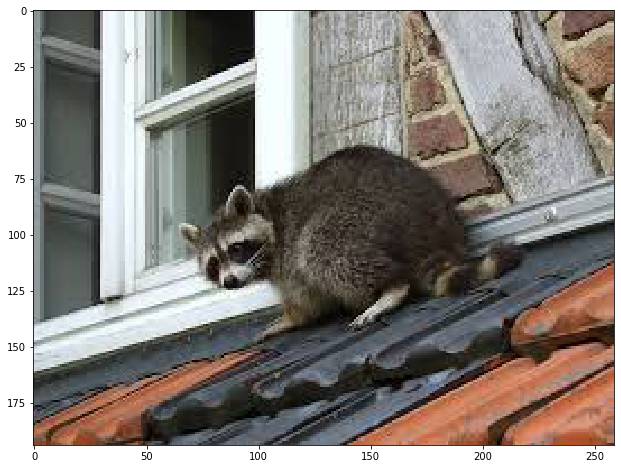

In [105]:
#Predict on random images in test dataset
image_num = np.random.randint(0, image_df.shape[0])
image_file = 'drive/My Drive/lab_residency9/lab_ext/images/' + image_df.loc[image_num, 'filename']
model_prediction(image_file)